成功讀取 Excel！

=== 市場分析摘要 (包含 IRR) ===
       City  NOI_CAGR_%  Avg_Vacancy_%  Avg_OER_%  Avg_Equity_Multiple  Avg_Equity_Growth_%  Avg_IRR_%
   Fairview         5.0       9.715523  57.561683             1.061568             6.156823   4.759600
   New Hope         6.0      10.010536  50.263068             1.079409             7.940876   7.303404
Springfield         1.0      10.246441  52.051686             1.049394             4.939437   4.026336


/var/folders/b1/672tkw4x48s5j8_p8n3dz5c40000gn/T/ipykernel_5521/1675528783.py:127: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary['City'], rotation=15, fontsize=9)
/var/folders/b1/672tkw4x48s5j8_p8n3dz5c40000gn/T/ipykernel_5521/1675528783.py:127: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary['City'], rotation=15, fontsize=9)
/var/folders/b1/672tkw4x48s5j8_p8n3dz5c40000gn/T/ipykernel_5521/1675528783.py:127: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary['City'], rotation=15, fontsize=9)
/var/folders/b1/672tkw4x48s5j8_p8n3dz5c40000gn/T/ipykernel_5521/1675528783.py:127: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_

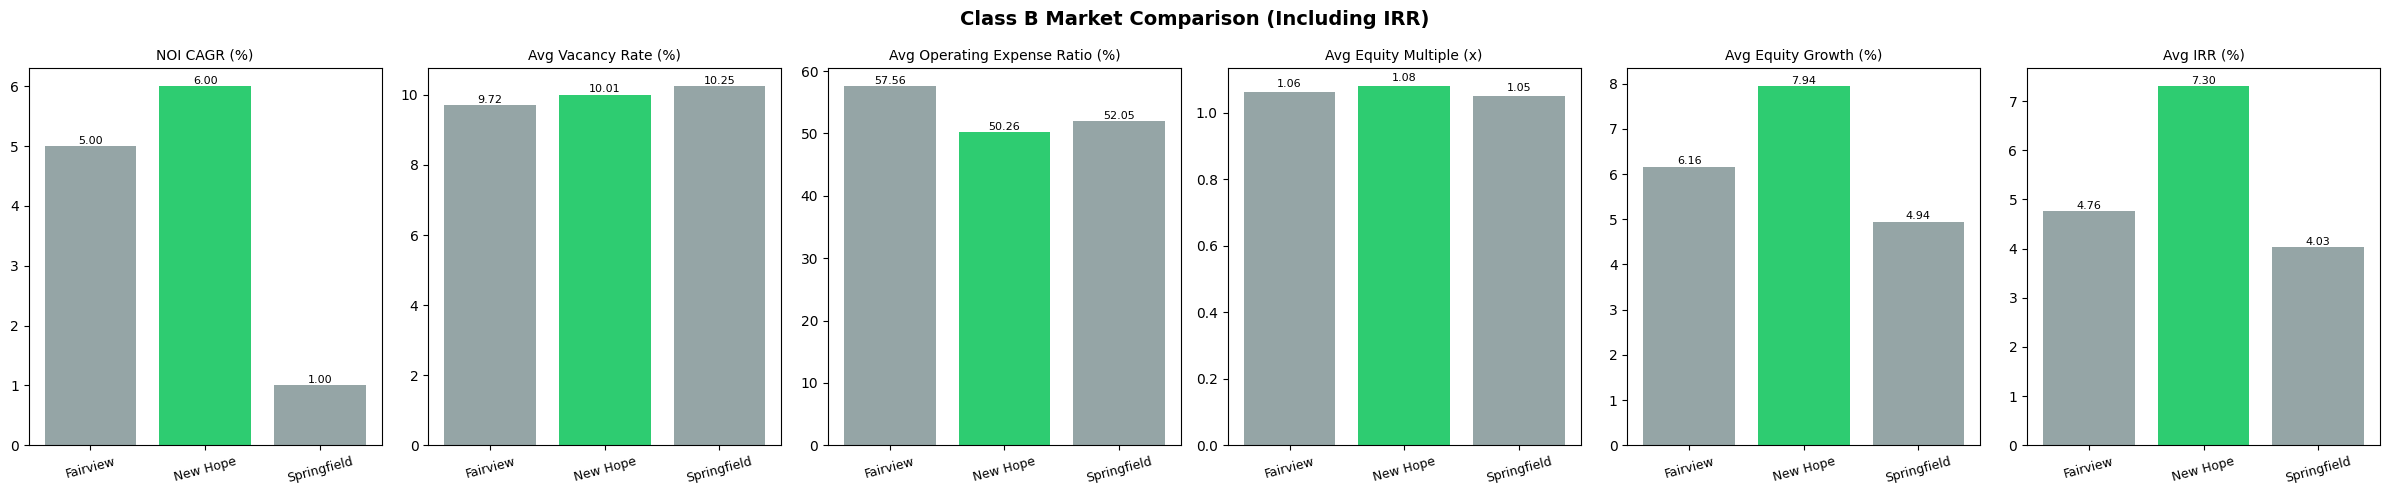

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── 1. 讀取資料 ───────────────────────────────────────
file_name = 'CRE_Data_SpringA2026.xlsx'

try:
    df_fin = pd.read_excel(file_name, sheet_name='Financials')
    df_eq  = pd.read_excel(file_name, sheet_name='Equity')
    print("成功讀取 Excel！")
except Exception as e:
    print(f"讀取失敗：{e}")

# ── 2. 篩選 Class B ───────────────────────────────────
df_fin_b = df_fin[df_fin['Class'] == 'B'].copy()

class_mapping = df_fin[['Building ID', 'Class']].drop_duplicates()
df_eq_b = df_eq.merge(class_mapping, left_on='Building', right_on='Building ID')
df_eq_b = df_eq_b[df_eq_b['Class'] == 'B'].copy()

# ── 3. 計算各指標 ─────────────────────────────────────

# A. NOI CAGR
def calculate_cagr(group):
    y1 = group[group['Year'] == 1]['Net Operating Income'].mean()
    y5 = group[group['Year'] == 5]['Net Operating Income'].mean()
    return round(((y5 / y1)**(1/4) - 1) * 100, 2)

# 注意：這裡使用新版 Pandas 的語法
noi_growth = df_fin_b.groupby('City').apply(calculate_cagr, include_groups=False).reset_index()
noi_growth.columns = ['City', 'NOI_CAGR_%']

# B. 平均空置率
df_fin_b['Vacancy_Rate'] = (df_fin_b['Lost Rent'] / df_fin_b['Gross Rental Income']) * 100
avg_vacancy = df_fin_b.groupby('City')['Vacancy_Rate'].mean().reset_index()
avg_vacancy.columns = ['City', 'Avg_Vacancy_%']

# C. 平均營業費用比率 (OER)
df_fin_b['OER'] = (df_fin_b['Operating Expenses'] / df_fin_b['Effective Gross Income']) * 100
avg_oer = df_fin_b.groupby('City')['OER'].mean().reset_index()
avg_oer.columns = ['City', 'Avg_OER_%']

# D. 股本倍數 (Equity Multiple)
df_eq_b['Equity_Multiple'] = df_eq_b['Equity Reversion'] / df_eq_b['Initial Equity Investment']
avg_em = df_eq_b.groupby('City')['Equity_Multiple'].mean().reset_index()
avg_em.columns = ['City', 'Avg_Equity_Multiple']

# E. 股權增長率
df_eq_b['Equity_Growth'] = (df_eq_b['Equity Reversion'] / df_eq_b['Initial Equity Investment'] - 1) * 100
avg_eg = df_eq_b.groupby('City')['Equity_Growth'].mean().reset_index()
avg_eg.columns = ['City', 'Avg_Equity_Growth_%']

# F. 計算 IRR (核心補充) ────────────────────────────────
def calculate_building_irr(b_id):
    # 取得初始投資與期末收益
    eq_row = df_eq_b[df_eq_b['Building'] == b_id]
    if eq_row.empty: return np.nan
    initial_inv = -eq_row['Initial Equity Investment'].iloc[0]
    reversion = eq_row['Equity Reversion'].iloc[0]
    
    # 取得 1-5 年的 NOI
    nois = df_fin_b[df_fin_b['Building ID'] == b_id].sort_values('Year')['Net Operating Income'].tolist()
    if len(nois) < 5: return np.nan
    
    # 建立現金流序列: [T0, T1, T2, T3, T4, T5 + Reversion]
    cash_flows = [initial_inv] + nois[:-1] + [nois[-1] + reversion]
    
    # 計算 IRR (使用 numpy 的 np.irr，若版本較新可能需用 np.roots)
    try:
        # 建立多項式係數來求解 IRR: sum(CF_t * (1/(1+r))^t) = 0
        # np.roots 會解出 1/(1+r) 的根
        coeffs = cash_flows[::-1]
        roots = np.roots(coeffs)
        # 尋找合理的實數根
        real_roots = roots[np.isreal(roots)].real
        valid_roots = real_roots[real_roots > 0]
        if len(valid_roots) == 0: return np.nan
        # 找最接近 1 的根 (對應 IRR 接近 0)
        best_root = valid_roots[np.argmin(np.abs(valid_roots - 1))]
        return (1/best_root - 1) * 100
    except:
        return np.nan

# 針對每個 Building ID 計算 IRR
building_irrs = pd.DataFrame({
    'Building ID': df_fin_b['Building ID'].unique()
})
building_irrs['IRR'] = building_irrs['Building ID'].apply(calculate_building_irr)

# 將 IRR 合併回城市級別
city_map = df_fin_b[['Building ID', 'City']].drop_duplicates()
building_irrs = building_irrs.merge(city_map, on='Building ID')
avg_irr = building_irrs.groupby('City')['IRR'].mean().reset_index()
avg_irr.columns = ['City', 'Avg_IRR_%']

# ── 4. 合併彙整表 ─────────────────────────────────────
summary = (noi_growth
           .merge(avg_vacancy, on='City')
           .merge(avg_oer,     on='City')
           .merge(avg_em,      on='City')
           .merge(avg_eg,      on='City')
           .merge(avg_irr,     on='City'))

print("\n=== 市場分析摘要 (包含 IRR) ===")
print(summary.to_string(index=False))

# ── 5. 視覺化 ─────────────────────────────────────────
colors = ['#2ecc71' if city == 'New Hope' else '#95a5a6' for city in summary['City']]

# 改成 1x6 的佈局，因為多了 IRR
fig, axes = plt.subplots(1, 6, figsize=(24, 5))
fig.suptitle('Class B Market Comparison (Including IRR)', fontsize=14, fontweight='bold')

metrics = [
    ('NOI_CAGR_%',          'NOI CAGR (%)'),
    ('Avg_Vacancy_%',        'Avg Vacancy Rate (%)'),
    ('Avg_OER_%',            'Avg Operating Expense Ratio (%)'),
    ('Avg_Equity_Multiple',  'Avg Equity Multiple (x)'),
    ('Avg_Equity_Growth_%',  'Avg Equity Growth (%)'),
    ('Avg_IRR_%',            'Avg IRR (%)'), # 新增
]

for ax, (col, title) in zip(axes, metrics):
    bars = ax.bar(summary['City'], summary[col], color=colors)
    ax.set_title(title, fontsize=10)
    ax.set_xticklabels(summary['City'], rotation=15, fontsize=9)
    
    # 在每個 bar 上顯示數值
    for bar, val in zip(bars, summary[col]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

=== Top 5 配比 ===
 Studio_Units  OneBR_Units  Total_Area          NPV
           55           30       80000 1.411584e+07
           56           29       79600 1.356568e+07
           57           28       79200 1.301551e+07
           58           27       78800 1.246535e+07
           59           26       78400 1.191519e+07

最佳配比：55 Studio + 30 1-Bedroom
總面積：   80,000 sq ft
預估 NPV： $14,115,842


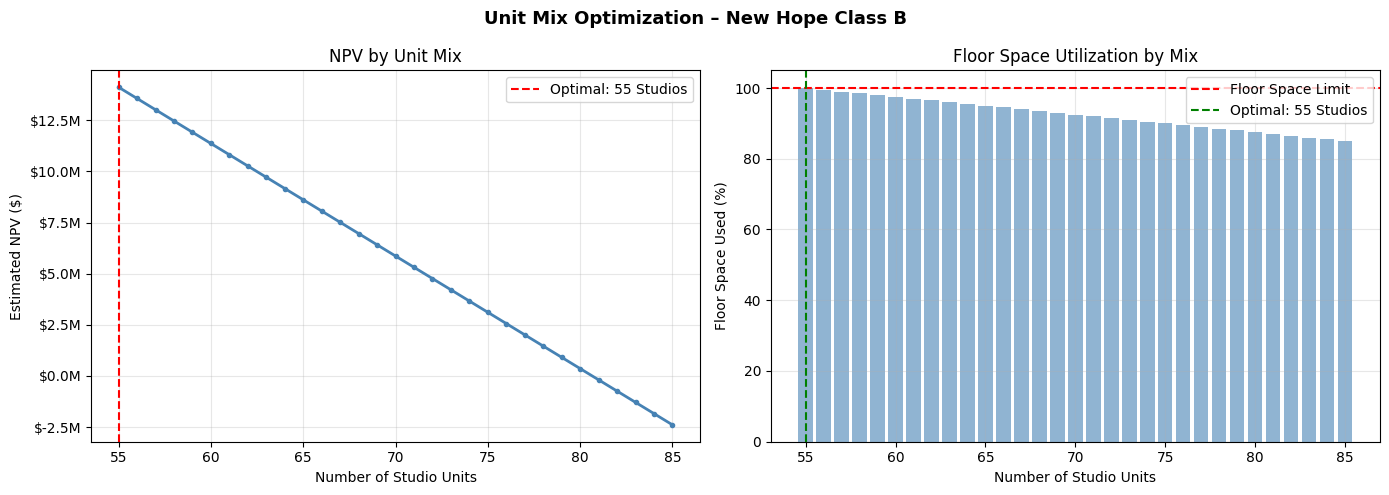

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. 基礎參數設定 ───────────────────────────────────
TOTAL_UNITS      = 85
MAX_FLOOR_SPACE  = 80000
STUDIO_SIZE      = 800
ONE_BR_SIZE      = 1200

ANNUAL_FIXED_COSTS     = 320000
STUDIO_VAR_COST_MONTH  = 720
ONE_BR_VAR_COST_MONTH  = 1000

DISCOUNT_RATE   = 0.10
HOLD_PERIOD     = 10
EXIT_CAP_RATE   = 0.06
RENT_GROWTH     = 0.06  # New Hope 歷史 Rent CAGR

START_RENT_STUDIO = 1832
START_RENT_1BR    = 2565

# ── 2. 市場需求上限（照 Memo 原文）────────────────────
def get_market_cap(rent, unit_type):
    if unit_type == 'studio':
        if rent < 1500:           return 60
        elif rent < 1800:         return 55
        elif rent < 2100:         return 48
        elif rent < 2500:         return 40
        elif rent < 2800:         return 30
        else:                     return 18
    else:  # 1-bedroom
        if rent < 1500:           return 75
        elif rent < 1800:         return 70
        elif rent < 2100:         return 65
        elif rent < 2500:         return 57
        elif rent < 2800:         return 48
        else:                     return 35

# ── 3. 核心模擬函數（NPV）────────────────────────────
def run_simulation(n_studio):
    n_1br      = TOTAL_UNITS - n_studio
    total_area = n_studio * STUDIO_SIZE + n_1br * ONE_BR_SIZE

    # 面積限制
    if total_area > MAX_FLOOR_SPACE:
        return None

    yearly_noi_pv = []
    curr_rent_s   = START_RENT_STUDIO
    curr_rent_b   = START_RENT_1BR

    for year in range(1, HOLD_PERIOD + 1):
        # 市場上限
        cap_s    = get_market_cap(curr_rent_s, 'studio')
        cap_b    = get_market_cap(curr_rent_b, '1br')

        # 實際租出數量
        leased_s = min(n_studio, cap_s)
        leased_b = min(n_1br,    cap_b)

        # 收入
        gross_income = (leased_s * curr_rent_s + leased_b * curr_rent_b) * 12

        # 支出（所有建造單位都要付變動成本）
        total_opex = (ANNUAL_FIXED_COSTS
                      + n_studio * STUDIO_VAR_COST_MONTH * 12
                      + n_1br    * ONE_BR_VAR_COST_MONTH * 12)

        noi = gross_income - total_opex
        yearly_noi_pv.append(noi / (1 + DISCOUNT_RATE) ** year)

        # 租金成長
        curr_rent_s *= (1 + RENT_GROWTH)
        curr_rent_b *= (1 + RENT_GROWTH)

    # Terminal Value（用第 11 年 NOI 估算）
    cap_s_end  = get_market_cap(curr_rent_s, 'studio')
    cap_b_end  = get_market_cap(curr_rent_b, '1br')
    rev_end    = (min(n_studio, cap_s_end) * curr_rent_s
                + min(n_1br,   cap_b_end) * curr_rent_b) * 12
    noi_end    = rev_end - total_opex
    terminal_v = (noi_end / EXIT_CAP_RATE) / (1 + DISCOUNT_RATE) ** HOLD_PERIOD

    return sum(yearly_noi_pv) + terminal_v

# ── 4. 遍歷所有合法配比 ───────────────────────────────
results = []
for s in range(0, TOTAL_UNITS + 1):
    npv = run_simulation(s)
    if npv is not None:
        n_b = TOTAL_UNITS - s
        results.append({
            'Studio_Units': s,
            'OneBR_Units':  n_b,
            'Total_Area':   s * STUDIO_SIZE + n_b * ONE_BR_SIZE,
            'NPV':          npv
        })

df_results = pd.DataFrame(results)
best       = df_results.loc[df_results['NPV'].idxmax()]

print("=== Top 5 配比 ===")
print(df_results.sort_values('NPV', ascending=False).head().to_string(index=False))
print(f"\n最佳配比：{int(best['Studio_Units'])} Studio + {int(best['OneBR_Units'])} 1-Bedroom")
print(f"總面積：   {int(best['Total_Area']):,} sq ft")
print(f"預估 NPV： ${best['NPV']:,.0f}")

# ── 5. 視覺化 ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Unit Mix Optimization – New Hope Class B', fontsize=13, fontweight='bold')

# 圖1：NPV 曲線
axes[0].plot(df_results['Studio_Units'], df_results['NPV'],
             color='steelblue', linewidth=2, marker='o', markersize=3)
axes[0].axvline(best['Studio_Units'], color='red', linestyle='--',
                label=f"Optimal: {int(best['Studio_Units'])} Studios")
axes[0].set_xlabel('Number of Studio Units')
axes[0].set_ylabel('Estimated NPV ($)')
axes[0].set_title('NPV by Unit Mix')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 圖2：各配比的面積使用率
axes[1].bar(df_results['Studio_Units'],
            df_results['Total_Area'] / MAX_FLOOR_SPACE * 100,
            color='steelblue', alpha=0.6)
axes[1].axhline(100, color='red', linestyle='--', label='Floor Space Limit')
axes[1].axvline(best['Studio_Units'], color='green', linestyle='--',
                label=f"Optimal: {int(best['Studio_Units'])} Studios")
axes[1].set_xlabel('Number of Studio Units')
axes[1].set_ylabel('Floor Space Used (%)')
axes[1].set_title('Floor Space Utilization by Mix')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== 敏感度分析：不同租金成長率下的最佳配比 ===
Rent Growth  Best Studio  Best 1BR         NPV
         2%           55        30 $12,446,058
         4%           55        30 $13,774,617
         6%           55        30 $14,115,842
         8%           55        30 $17,490,803
        10%           55        30 $21,774,243


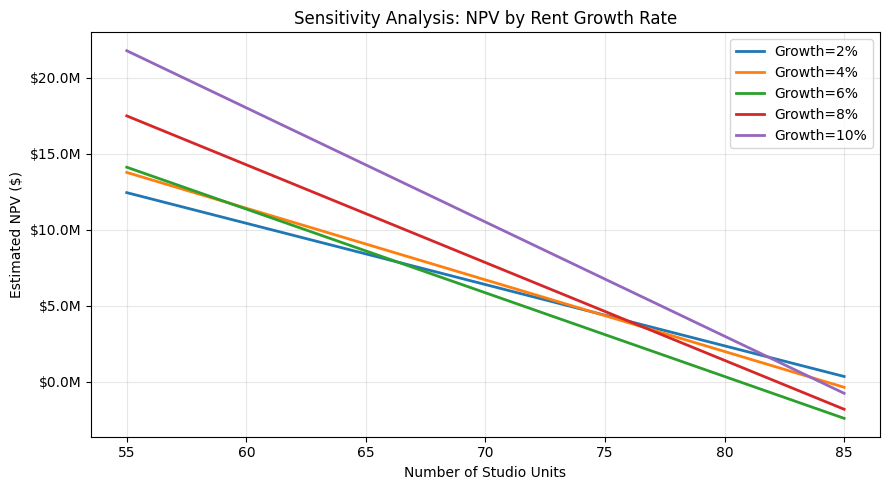

In [22]:
# ── 敏感度分析：租金成長率對最佳配比 NPV 的影響 ──────
growth_rates = [0.02, 0.04, 0.06, 0.08, 0.10]
sensitivity  = []

for g in growth_rates:
    RENT_GROWTH = g
    npv_list = []
    for s in range(0, TOTAL_UNITS + 1):
        n_b       = TOTAL_UNITS - s
        total_area = s * STUDIO_SIZE + n_b * ONE_BR_SIZE
        if total_area > MAX_FLOOR_SPACE:
            continue

        curr_rent_s = START_RENT_STUDIO
        curr_rent_b = START_RENT_1BR
        yearly_pv   = []
        for year in range(1, HOLD_PERIOD + 1):
            cap_s    = get_market_cap(curr_rent_s, 'studio')
            cap_b    = get_market_cap(curr_rent_b, '1br')
            leased_s = min(s,   cap_s)
            leased_b = min(n_b, cap_b)
            gross    = (leased_s * curr_rent_s + leased_b * curr_rent_b) * 12
            opex     = ANNUAL_FIXED_COSTS + s * STUDIO_VAR_COST_MONTH * 12 + n_b * ONE_BR_VAR_COST_MONTH * 12
            noi      = gross - opex
            yearly_pv.append(noi / (1 + DISCOUNT_RATE) ** year)
            curr_rent_s *= (1 + g)
            curr_rent_b *= (1 + g)
        cap_s_end = get_market_cap(curr_rent_s, 'studio')
        cap_b_end = get_market_cap(curr_rent_b, '1br')
        rev_end   = (min(s, cap_s_end) * curr_rent_s + min(n_b, cap_b_end) * curr_rent_b) * 12
        tv        = (rev_end - opex) / EXIT_CAP_RATE / (1 + DISCOUNT_RATE) ** HOLD_PERIOD
        npv_list.append({'Studio': s, 'NPV': sum(yearly_pv) + tv})

    df_g   = pd.DataFrame(npv_list)
    best_g = df_g.loc[df_g['NPV'].idxmax()]
    sensitivity.append({
        'Rent Growth': f"{g*100:.0f}%",
        'Best Studio': int(best_g['Studio']),
        'Best 1BR':    TOTAL_UNITS - int(best_g['Studio']),
        'NPV':         f"${best_g['NPV']:,.0f}"
    })

df_sens = pd.DataFrame(sensitivity)
print("=== 敏感度分析：不同租金成長率下的最佳配比 ===")
print(df_sens.to_string(index=False))

# 視覺化敏感度
fig, ax = plt.subplots(figsize=(9, 5))
for g in growth_rates:
    RENT_GROWTH = g
    npv_curve = []
    for s in range(0, TOTAL_UNITS + 1):
        n_b = TOTAL_UNITS - s
        if s * STUDIO_SIZE + n_b * ONE_BR_SIZE > MAX_FLOOR_SPACE:
            continue
        curr_rent_s, curr_rent_b = START_RENT_STUDIO, START_RENT_1BR
        yearly_pv = []
        for year in range(1, HOLD_PERIOD + 1):
            leased_s = min(s,   get_market_cap(curr_rent_s, 'studio'))
            leased_b = min(n_b, get_market_cap(curr_rent_b, '1br'))
            gross    = (leased_s * curr_rent_s + leased_b * curr_rent_b) * 12
            opex     = ANNUAL_FIXED_COSTS + s * STUDIO_VAR_COST_MONTH * 12 + n_b * ONE_BR_VAR_COST_MONTH * 12
            yearly_pv.append((gross - opex) / (1 + DISCOUNT_RATE) ** year)
            curr_rent_s *= (1 + g); curr_rent_b *= (1 + g)
        leased_s = min(s,   get_market_cap(curr_rent_s, 'studio'))
        leased_b = min(n_b, get_market_cap(curr_rent_b, '1br'))
        rev_end  = (leased_s * curr_rent_s + leased_b * curr_rent_b) * 12
        tv       = (rev_end - opex) / EXIT_CAP_RATE / (1 + DISCOUNT_RATE) ** HOLD_PERIOD
        npv_curve.append({'Studio': s, 'NPV': sum(yearly_pv) + tv})
    df_c = pd.DataFrame(npv_curve)
    ax.plot(df_c['Studio'], df_c['NPV'], label=f'Growth={g*100:.0f}%', linewidth=2)

ax.set_xlabel('Number of Studio Units')
ax.set_ylabel('Estimated NPV ($)')
ax.set_title('Sensitivity Analysis: NPV by Rent Growth Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Top 5 配比方案分析 ===
 Studio_Units  OneBR_Units  Total_Area          NPV
           55           30       80000 1.411584e+07
           56           29       79600 1.356568e+07
           57           28       79200 1.301551e+07
           58           27       78800 1.246535e+07
           59           26       78400 1.191519e+07

最佳建議方案：55 Studio + 30 1-Bedroom
總樓地板面積： 80,000 sq ft
預估專案 NPV： $14,115,842


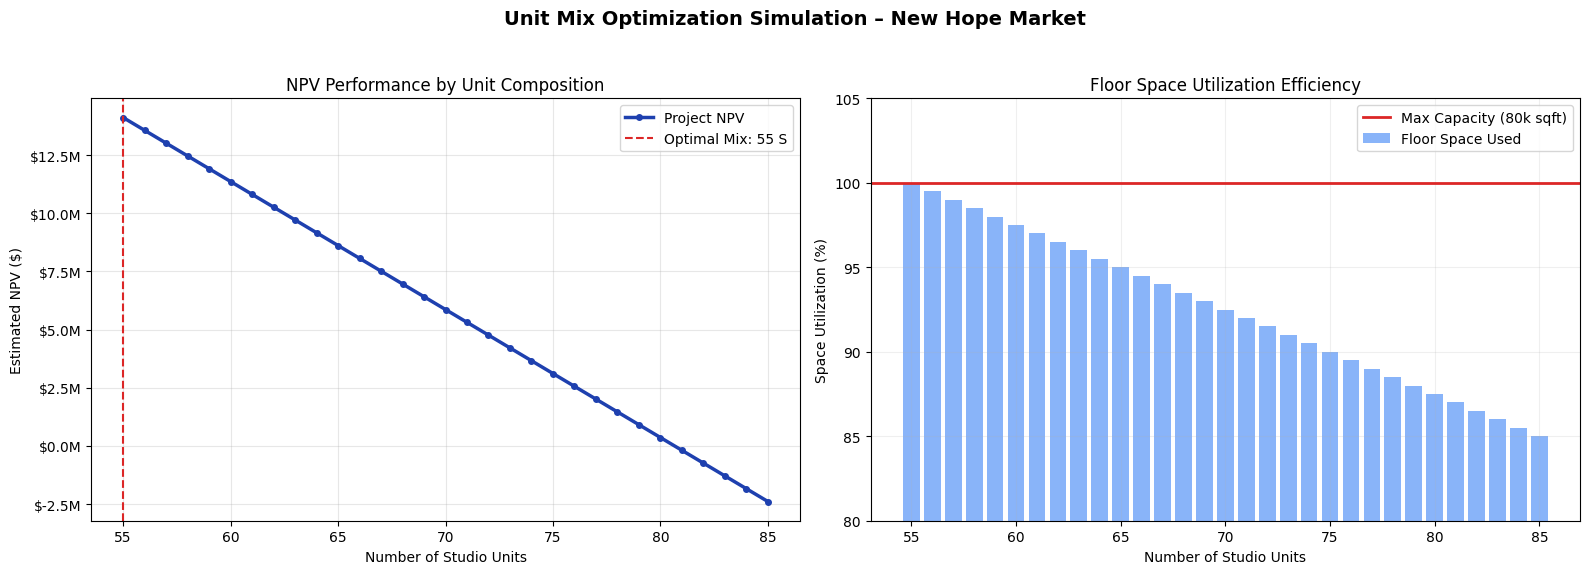

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. 基礎參數設定 (依據 Skyline Assumptions Memo) ───────────────────
TOTAL_UNITS      = 85
MAX_FLOOR_SPACE  = 80000
STUDIO_SIZE      = 800
ONE_BR_SIZE      = 1200

ANNUAL_FIXED_COSTS     = 320000
STUDIO_VAR_COST_MONTH  = 720
ONE_BR_VAR_COST_MONTH  = 1000

DISCOUNT_RATE   = 0.10
HOLD_PERIOD     = 10
EXIT_CAP_RATE   = 0.06
RENT_GROWTH     = 0.06  # 基於 New Hope 歷史 Rent CAGR

# 使用 New Hope Class B 市場平均起始租金
START_RENT_STUDIO = 1832
START_RENT_1BR    = 2565

# ── 2. 市場需求上限 (依據 Memo 正確數值進行修正) ──────────────────────
def get_market_cap(rent, unit_type):
    """依據租金水平回傳該單位的市場最大消化量"""
    if unit_type == 'studio':
        if rent < 1500:           return 60
        elif rent < 1800:         return 55
        elif rent < 2100:         return 48
        elif rent < 2500:         return 40
        elif rent < 2800:         return 30
        else:                     return 18
    else:  # 1-bedroom
        if rent < 1500:           return 75
        elif rent < 1800:         return 70
        elif rent < 2100:         return 65
        elif rent < 2500:         return 57
        elif rent < 2800:         return 48
        else:                     return 35

# ── 3. 核心模擬函數 (NPV) ────────────────────────────
def run_simulation(n_studio):
    n_1br      = TOTAL_UNITS - n_studio
    total_area = n_studio * STUDIO_SIZE + n_1br * ONE_BR_SIZE

    # 面積限制檢查 (Constraint: Total Floor Space <= 80,000)
    if total_area > MAX_FLOOR_SPACE:
        return None

    yearly_noi_pv = []
    curr_rent_s   = START_RENT_STUDIO
    curr_rent_b   = START_RENT_1BR

    # 10 年營運期模擬
    for year in range(1, HOLD_PERIOD + 1):
        # 獲取該年份租金下的市場上限
        cap_s = get_market_cap(curr_rent_s, 'studio')
        cap_b = get_market_cap(curr_rent_b, '1br')

        # 實際租出數量 (不能超過建造數，也不能超過市場上限)
        leased_s = min(n_studio, cap_s)
        leased_b = min(n_1br,    cap_b)

        # 收入計算 (Leased units * Monthly Rent * 12)
        gross_income = (leased_s * curr_rent_s + leased_b * curr_rent_b) * 12

        # 支出計算 (所有建造單位皆須負擔變動成本，不論是否租出)
        total_opex = (ANNUAL_FIXED_COSTS 
                      + n_studio * STUDIO_VAR_COST_MONTH * 12 
                      + n_1br    * ONE_BR_VAR_COST_MONTH * 12)

        noi = gross_income - total_opex
        
        # 折現回現值 (Present Value)
        yearly_noi_pv.append(noi / (1 + DISCOUNT_RATE) ** year)

        # 租金逐年成長 (CAGR 6%)
        curr_rent_s *= (1 + RENT_GROWTH)
        curr_rent_b *= (1 + RENT_GROWTH)

    # ── 4. Terminal Value (用第 11 年預估 NOI 進行估算) ─────────────────
    cap_s_y11 = get_market_cap(curr_rent_s, 'studio')
    cap_b_y11 = get_market_cap(curr_rent_b, '1br')
    
    rev_y11 = (min(n_studio, cap_s_y11) * curr_rent_s + 
               min(n_1br,   cap_b_y11) * curr_rent_b) * 12
    noi_y11 = rev_y11 - total_opex
    
    # 退出價值折現 (TV at Year 10, Exit Cap Rate 6%)
    terminal_v = (noi_y11 / EXIT_CAP_RATE) / (1 + DISCOUNT_RATE) ** HOLD_PERIOD

    return sum(yearly_noi_pv) + terminal_v

# ── 5. 遍歷所有合法配比 (Total Units = 85) ─────────────────────────
results = []
for s in range(0, TOTAL_UNITS + 1):
    npv = run_simulation(s)
    if npv is not None:
        n_b = TOTAL_UNITS - s
        results.append({
            'Studio_Units': s,
            'OneBR_Units':  n_b,
            'Total_Area':   s * STUDIO_SIZE + n_b * ONE_BR_SIZE,
            'NPV':          npv
        })

df_results = pd.DataFrame(results)
best       = df_results.loc[df_results['NPV'].idxmax()]

# ── 6. 輸出結果 ─────────────────────────────────────────
print("=== Top 5 配比方案分析 ===")
print(df_results.sort_values('NPV', ascending=False).head().to_string(index=False))
print(f"\n最佳建議方案：{int(best['Studio_Units'])} Studio + {int(best['OneBR_Units'])} 1-Bedroom")
print(f"總樓地板面積： {int(best['Total_Area']):,} sq ft")
print(f"預估專案 NPV： ${best['NPV']:,.0f}")

# ── 7. 視覺化呈現 ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Unit Mix Optimization Simulation – New Hope Market', fontsize=14, fontweight='bold')

# 圖 1：NPV 曲線分析
axes[0].plot(df_results['Studio_Units'], df_results['NPV'], 
             color='#1e40af', linewidth=2.5, marker='o', markersize=4, label='Project NPV')
axes[0].axvline(best['Studio_Units'], color='#dc2626', linestyle='--', 
                label=f"Optimal Mix: {int(best['Studio_Units'])} S")
axes[0].set_xlabel('Number of Studio Units')
axes[0].set_ylabel('Estimated NPV ($)')
axes[0].set_title('NPV Performance by Unit Composition')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 圖 2：空間利用率分析 (確保不超過 80,000 sq ft)
utilization = df_results['Total_Area'] / MAX_FLOOR_SPACE * 100
axes[1].bar(df_results['Studio_Units'], utilization, color='#3b82f6', alpha=0.6, label='Floor Space Used')
axes[1].axhline(100, color='#dc2626', linestyle='-', linewidth=2, label='Max Capacity (80k sqft)')
axes[1].set_ylim(80, 105) # 聚焦於高利用率區間
axes[1].set_xlabel('Number of Studio Units')
axes[1].set_ylabel('Space Utilization (%)')
axes[1].set_title('Floor Space Utilization Efficiency')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [9]:
import pandas as pd

# ── 1. 基礎參數設定 (從 Section 2 繼承) ───────────────────
TOTAL_UNITS      = 85
MAX_FLOOR_SPACE  = 80000
STUDIO_SIZE      = 800
ONE_BR_SIZE      = 1200

ANNUAL_FIXED_COSTS     = 320000
STUDIO_VAR_COST_MONTH  = 720
ONE_BR_VAR_COST_MONTH  = 1000

DISCOUNT_RATE   = 0.10
HOLD_PERIOD     = 10
EXIT_CAP_RATE   = 0.06

START_RENT_STUDIO = 1832
START_RENT_1BR    = 2565

# ── 2. 市場需求上限 ─────────────────────────
def get_market_cap(rent, unit_type):
    if unit_type == 'studio':
        if rent < 1500:           return 60
        elif rent < 1800:         return 55
        elif rent < 2100:         return 48
        elif rent < 2500:         return 40
        elif rent < 2800:         return 30
        else:                     return 18
    else:  # 1-bedroom
        if rent < 1500:           return 75
        elif rent < 1800:         return 70
        elif rent < 2100:         return 65
        elif rent < 2500:         return 57
        elif rent < 2800:         return 48
        else:                     return 35

# ── 3. 加上壓力測試參數的 NPV 計算函數 ────────────────────────────
def run_simulation_adjusted(n_studio, n_1br, growth, vac_adj, cost_mult):
    total_area = n_studio * STUDIO_SIZE + n_1br * ONE_BR_SIZE
    if total_area > MAX_FLOOR_SPACE:
        return None

    yearly_noi_pv = []
    curr_rent_s   = START_RENT_STUDIO
    curr_rent_b   = START_RENT_1BR

    for year in range(1, HOLD_PERIOD + 1):
        cap_s = get_market_cap(curr_rent_s, 'studio')
        cap_b = get_market_cap(curr_rent_b, '1br')

        leased_s = min(n_studio, cap_s)
        leased_b = min(n_1br,    cap_b)

        # 收入計算：扣除額外的空置率 (Vacancy Adjustment)
        gross_income = (leased_s * curr_rent_s + leased_b * curr_rent_b) * 12
        effective_gross_income = gross_income * (1 - vac_adj)

        # 支出計算：乘上成本增加倍數 (Cost Multiplier)
        total_opex = (ANNUAL_FIXED_COSTS * cost_mult
                      + n_studio * STUDIO_VAR_COST_MONTH * 12 * cost_mult
                      + n_1br    * ONE_BR_VAR_COST_MONTH * 12 * cost_mult)

        noi = effective_gross_income - total_opex
        yearly_noi_pv.append(noi / (1 + DISCOUNT_RATE) ** year)

        # 租金使用壓力測試下的成長率
        curr_rent_s *= (1 + growth)
        curr_rent_b *= (1 + growth)

    # ── 4. Terminal Value ─────────────────
    cap_s_y11 = get_market_cap(curr_rent_s, 'studio')
    cap_b_y11 = get_market_cap(curr_rent_b, '1br')
    
    rev_y11 = (min(n_studio, cap_s_y11) * curr_rent_s + 
               min(n_1br,   cap_b_y11) * curr_rent_b) * 12
    effective_rev_y11 = rev_y11 * (1 - vac_adj)
    
    # 注意第 11 年的成本也要乘上倍數
    total_opex_y11 = (ANNUAL_FIXED_COSTS * cost_mult
                      + n_studio * STUDIO_VAR_COST_MONTH * 12 * cost_mult
                      + n_1br    * ONE_BR_VAR_COST_MONTH * 12 * cost_mult)
                      
    noi_y11 = effective_rev_y11 - total_opex_y11
    terminal_v = (noi_y11 / EXIT_CAP_RATE) / (1 + DISCOUNT_RATE) ** HOLD_PERIOD

    return sum(yearly_noi_pv) + terminal_v

# ── 5. 執行壓力測試腳本 ───────────────────────────────
best_s = 55
best_b = 30

scenarios = [
    {"Name": "Base Case", "Growth": 0.06, "Vac_Adj": 0.0, "Cost_Mult": 1.0},
    {"Name": "Mild Downside", "Growth": 0.05, "Vac_Adj": 0.005, "Cost_Mult": 1.05},
    {"Name": "Downside Case", "Growth": 0.04, "Vac_Adj": 0.01, "Cost_Mult": 1.10},
    {"Name": "Severe Case", "Growth": 0.03, "Vac_Adj": 0.02, "Cost_Mult": 1.15}
]

stress_results = []

for sc in scenarios:
    npv = run_simulation_adjusted(
        n_studio=best_s, 
        n_1br=best_b, 
        growth=sc["Growth"], 
        vac_adj=sc["Vac_Adj"],
        cost_mult=sc["Cost_Mult"]
    )
    stress_results.append({
        "Scenario": sc["Name"],
        "Rent Growth": f"{sc['Growth']*100}%",
        "Cost Increase": f"{(sc['Cost_Mult']-1)*100:.0f}%",
        "Estimated NPV": f"${npv:,.0f}",
        "Status": "Positive (Safe)" if npv > 0 else "Negative (Risk)"
    })

df_stress = pd.DataFrame(stress_results)
print("=== 55 Studio / 30 1-Bedroom 組合下行壓力測試結果 ===")
print(df_stress.to_string(index=False))

=== 55 Studio / 30 1-Bedroom 組合下行壓力測試結果 ===
     Scenario Rent Growth Cost Increase Estimated NPV          Status
    Base Case        6.0%            0%   $14,115,842 Positive (Safe)
Mild Downside        5.0%            5%   $11,723,171 Positive (Safe)
Downside Case        4.0%           10%   $12,039,539 Positive (Safe)
  Severe Case        3.0%           15%   $11,408,646 Positive (Safe)
